# Customer Churn Prediction and Risk Segmentation
---

## Business Problem

Telecom companies lose customers every month due to competitive pricing, service issues, and changing customer preferences. Customer churn directly impacts revenue and long-term business growth.

Acquiring a new customer is significantly more expensive than retaining an existing one, making customer retention a key priority for telecom companies. Therefore, identifying customers who are likely to churn and understanding the factors driving churn is essential for implementing proactive retention strategies.

The objective of this project is to build a machine learning system capable of predicting customer churn and identifying high-risk customers who may discontinue their services.

---

## Project Overview

This project uses historical telecom customer data to analyze customer behavior and develop a predictive model for churn.

The analysis begins with **exploratory data analysis (EDA)** to identify patterns and relationships between customer characteristics and churn behavior. Feature engineering techniques and machine learning pipelines are implemented to ensure a consistent and reproducible modeling workflow.

Multiple machine learning models were evaluated, including **Logistic Regression, Random Forest, and XGBoost**. Among these models, the **Random Forest model achieved the highest recall for churn customers** and was selected as the final model.

The model's predicted churn probabilities are then used to segment customers into **Low Risk, Medium Risk, and High Risk groups**, allowing businesses to prioritize retention strategies and focus on customers most likely to churn.

---

## Project Objectives

The main objectives of this project are:

- Identify key factors that influence customer churn
- Build a machine learning model to predict churn probability
- Compare multiple models to select the best-performing approach
- Segment customers based on churn risk levels
- Provide actionable insights to support customer retention strategies

---

## Tools and Technologies

- **Python**
- **Pandas and NumPy** for data analysis
- **Matplotlib and Seaborn** for data visualization
- **Scikit-learn** for machine learning pipelines and modeling
- **XGBoost** for gradient boosting models

## Understanding the Dataset
---

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

# display settings
pd.set_option("display.max_columns", None)

import sys
import os

sys.path.append(os.path.abspath(".."))

In [82]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')

In [83]:
(df.sample(10))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1398,3569-EDBPQ,Female,0,No,No,24,Yes,Yes,Fiber optic,Yes,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,84.35,1938.05,No
4202,3146-JTQHR,Male,0,Yes,No,10,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),19.60,189.45,No
1685,9365-SRSZE,Male,1,Yes,No,27,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.55,1943.9,No
605,4723-BEGSG,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),86.65,6094.25,No
3530,1703-MGIAB,Female,0,No,No,17,Yes,Yes,DSL,No,No,Yes,Yes,Yes,No,Month-to-month,Yes,Mailed check,69.00,1108,No
3116,9391-DXGGG,Female,1,No,No,44,Yes,No,Fiber optic,No,Yes,Yes,No,No,Yes,One year,No,Credit card (automatic),89.15,3990.75,No
223,0742-MOABM,Male,0,Yes,No,4,Yes,No,DSL,No,No,No,Yes,No,No,Month-to-month,No,Mailed check,50.05,179.35,Yes
721,8434-VGEQQ,Male,0,Yes,Yes,61,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),20.55,1305.95,No
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
1542,9798-OPFEM,Female,0,No,No,46,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Electronic check,21.10,937.1,No


In [84]:
df.shape

(7043, 21)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [86]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [87]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [88]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

Dataset is imbalanced

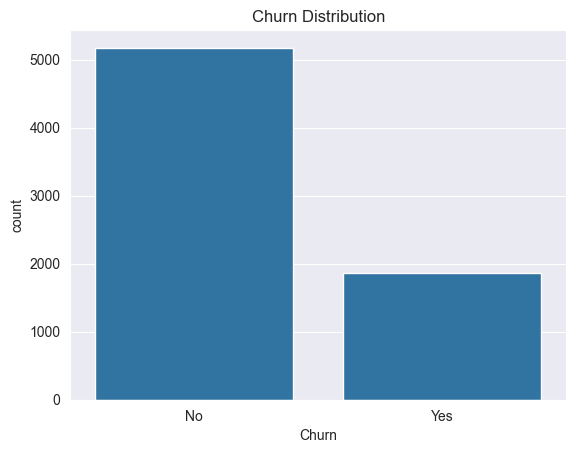

In [89]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

In [90]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [91]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [92]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [93]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [94]:
df = df.dropna()

In [95]:
df.shape

(7032, 21)

In [96]:
df = df.drop("customerID", axis=1)

In [97]:
df.duplicated().sum()

np.int64(22)

In [98]:
df = df.drop_duplicates()

In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
df.shape

(7010, 20)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   object 
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   object 
 3   Dependents        7010 non-null   object 
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   object 
 6   MultipleLines     7010 non-null   object 
 7   InternetService   7010 non-null   object 
 8   OnlineSecurity    7010 non-null   object 
 9   OnlineBackup      7010 non-null   object 
 10  DeviceProtection  7010 non-null   object 
 11  TechSupport       7010 non-null   object 
 12  StreamingTV       7010 non-null   object 
 13  StreamingMovies   7010 non-null   object 
 14  Contract          7010 non-null   object 
 15  PaperlessBilling  7010 non-null   object 
 16  PaymentMethod     7010 non-null   object 
 17  

The dataset contains data of 7010 customers across 20 features.

## Exploratory Data Analysis
---

In [102]:
df["Churn"].value_counts()

Churn
No     5153
Yes    1857
Name: count, dtype: int64

In [103]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.509272
Yes    26.490728
Name: proportion, dtype: float64

About 1 out of 4 customers churn

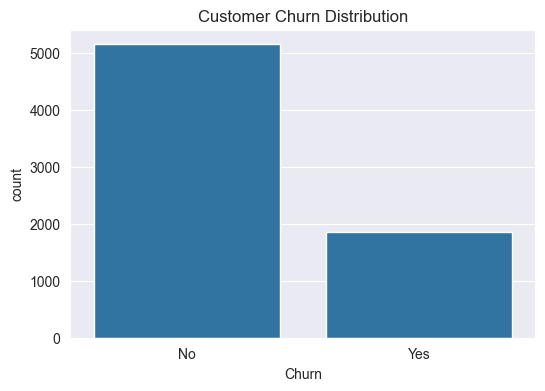

In [104]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

Dataset is imbalanced

In [105]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7010.000000,7010.000000,7010.000000,7010.000000
mean,0.162767,32.520399,64.888666,2290.353388
std,0.369180,24.520441,30.064769,2266.820832
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.750000,408.312500
50%,0.000000,29.000000,70.400000,1403.875000
75%,0.000000,56.000000,89.900000,3807.837500
max,1.000000,72.000000,118.750000,8684.800000


### 1. Churn vs Tenure

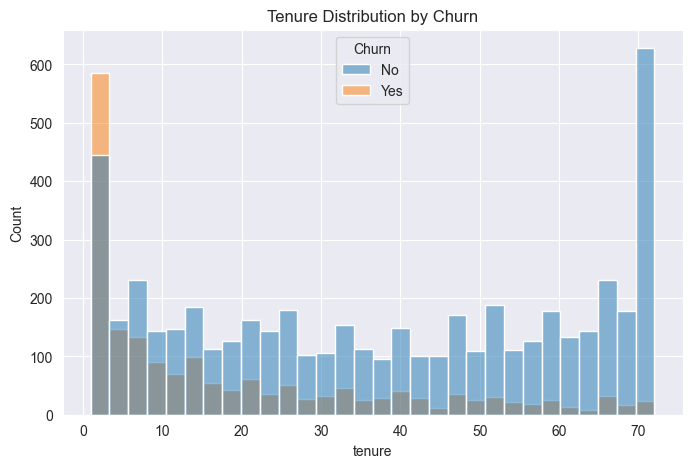

In [106]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, alpha=0.5)
plt.title("Tenure Distribution by Churn")
plt.show()

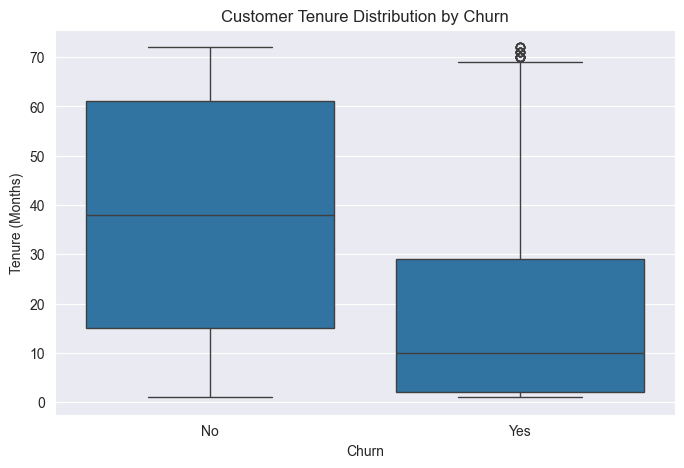

In [107]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Customer Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

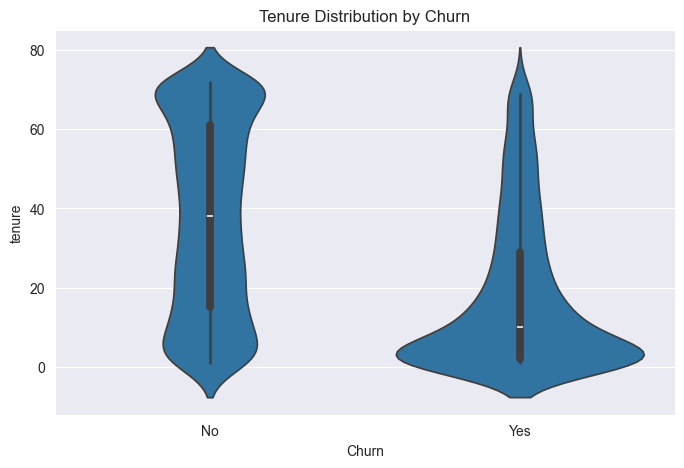

In [108]:
plt.figure(figsize=(8,5))

sns.violinplot(x="Churn", y="tenure", data=df)

plt.title("Tenure Distribution by Churn")

plt.show()

Lower the tenure, higher is the risk of churn.

Customer churn risk is highest in the early months.

So companies should focus on first 3–6 months of customer experience.

Example strategy:
* Free upgrade for first 3 months
* Welcome discount
* Better onboarding


Many customers have tenure around 70 months, that means there are many long term loyal customers.

### 2. Churn vs Monthly charges

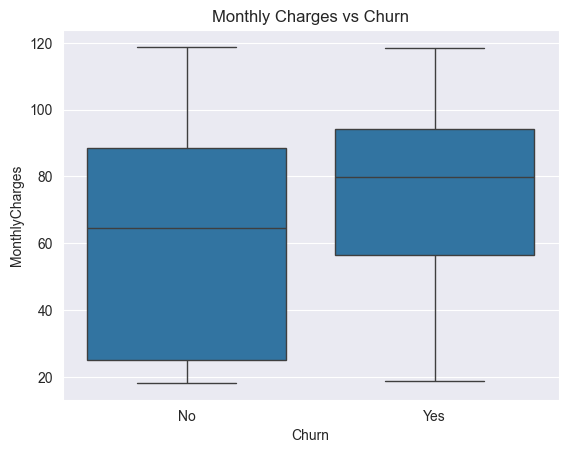

In [109]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")
plt.show()

Customers with higher monthly charges appear more likely to churn, suggesting pricing sensitivity may influence customer retention.

### 3. Contract Type vs Churn

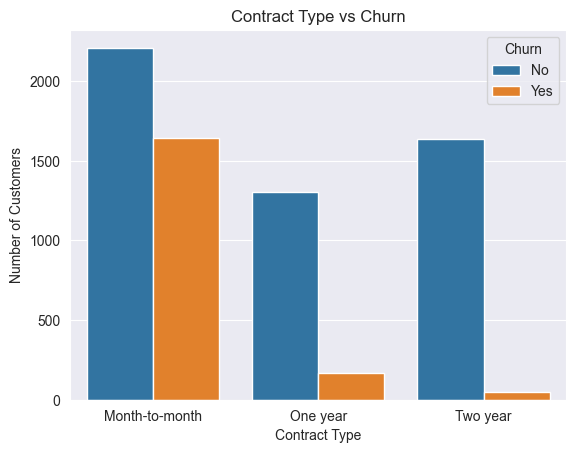

In [110]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

Customers on month-to-month contracts exhibit significantly higher churn rates compared to customers with long-term contracts. This suggests that long-term contractual commitments improve customer retention.

In [111]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.357903,42.642097
One year,88.722826,11.277174
Two year,97.151335,2.848665


* Month-to-month  → Highest churn
* One year        → Moderate churn
* Two year        → Lowest churn

Customers on month-to-month contracts show significantly higher churn rates compared to customers with one-year or two-year contracts. Long-term contracts appear to improve customer retention by increasing commitment and reducing switching behavior.

### 4. Tech support vs Churn

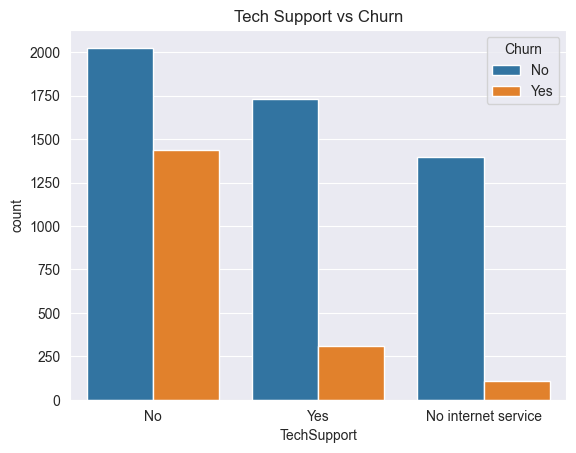

In [112]:
sns.countplot(x='TechSupport', hue='Churn', data=df)

plt.title("Tech Support vs Churn")

plt.show()

Customers without tech support services show significantly higher churn rates compared to customers who receive technical assistance. This suggests that customer support services play a crucial role in customer retention.

### 5. Monthly Charges vs Churn

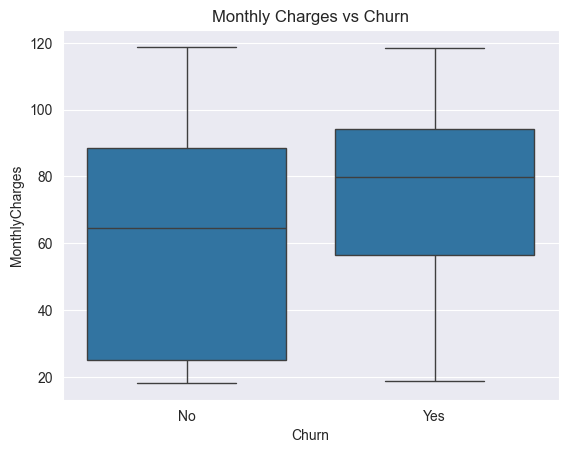

In [113]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

Customers with higher monthly charges exhibit a higher tendency to churn. This suggests that pricing sensitivity may influence customer retention, and customers may switch to competitors offering lower-priced services.

### 6. Tenure vs Churn

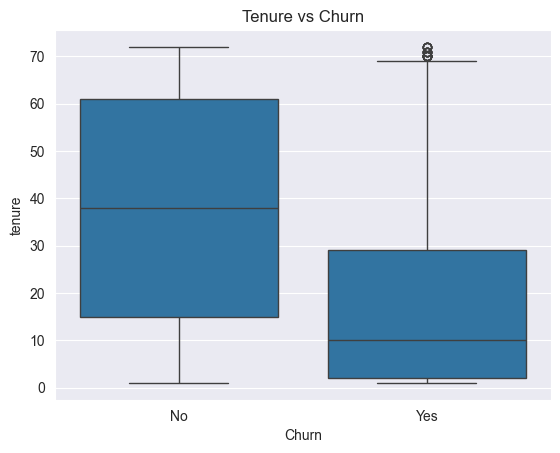

In [114]:
sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Tenure vs Churn")

plt.show()

Customers with lower tenure are significantly more likely to churn compared to long-term customers. This indicates that customer churn primarily occurs during the early stages of the customer lifecycle.

### 7. Total Charges vs Churn

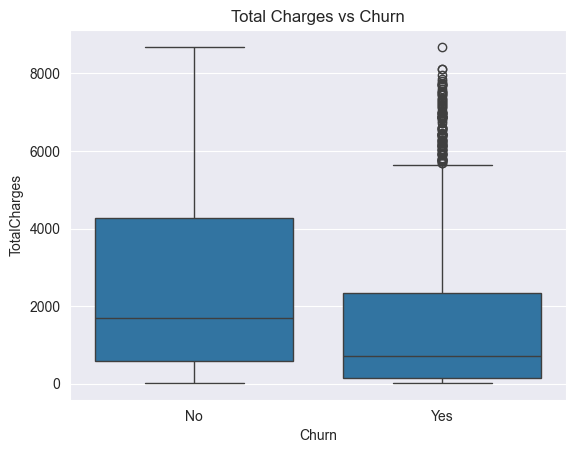

In [115]:
sns.boxplot(x='Churn', y='TotalCharges', data=df)

plt.title("Total Charges vs Churn")

plt.show()

Customers with higher charges show a greater tendency to churn. This indicates that pricing may influence customer retention, and customers paying higher fees may switch to alternative providers offering better value.

## Statistical Analysis
---
While exploratory data analysis revealed several patterns between customer characteristics and churn behavior, visual analysis alone is not sufficient to establish statistical significance. Therefore, statistical tests are applied to validate whether the observed relationships are meaningful or occur by random chance.

These tests provide quantitative evidence for the relationships between key variables and churn, strengthening the reliability of the insights and supporting data-driven business decisions.

### 1. _T-Test_: Monthly Charges vs Churn

A two-sample T-test is performed to determine whether the average monthly charges differ significantly between customers who churn and those who remain with the company.

Hypotheses:

H₀ (Null Hypothesis): There is no significant difference in the average monthly charges between churned and non-churned customers.

H₁ (Alternative Hypothesis): There is a significant difference in the average monthly charges between churned and non-churned customers.

If the p-value is less than 0.05, we reject the null hypothesis and conclude that monthly charges have a statistically significant relationship with churn.

In [116]:
# Separate groups
churn_yes = df[df['Churn'] == 'Yes']['MonthlyCharges']
churn_no = df[df['Churn'] == 'No']['MonthlyCharges']

# Perform T-test
t_stat, p_value = ttest_ind(churn_yes, churn_no)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 16.555739529770477
P-value: 2.0218234870798802e-60


### Interpretation

The p-value obtained from the T-test is extremely small (p < 0.05), which means we reject the null hypothesis.

This indicates that the difference in average monthly charges between churned and non-churned customers is statistically significant.

Therefore, monthly charges appear to have a significant relationship with customer churn. Customers paying higher monthly charges are more likely to leave the service.

### Business Insight

From a business perspective, this result suggests that pricing may play a role in customer retention. Customers with higher monthly charges may be more sensitive to cost and may switch to competitors offering lower prices.

### 2. _Chi-Square Test_: Contract Type vs Churn

The Chi-Square Test of Independence is used to determine whether there is a statistically significant relationship between contract type and customer churn.

Hypotheses:

H₀ (Null Hypothesis): Contract type and customer churn are independent. Contract type does not influence churn.

H₁ (Alternative Hypothesis): Contract type and customer churn are not independent. Contract type has a significant relationship with churn.

If the p-value is less than 0.05, we reject the null hypothesis and conclude that contract type significantly affects customer churn.

In [117]:
# Create contingency table
contingency_table = pd.crosstab(df['Contract'], df['Churn'])

# Perform Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 1174.7684225475446
P-value: 7.985061892265959e-256
Degrees of Freedom: 2


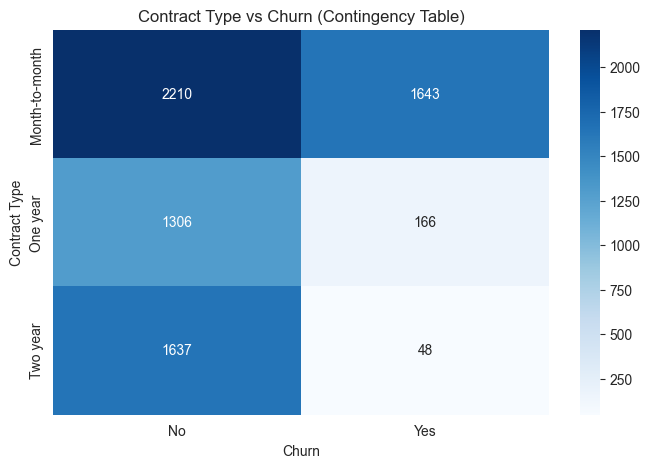

In [118]:
plt.figure(figsize=(8,5))

sns.heatmap(contingency_table,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Contract Type vs Churn (Contingency Table)")
plt.xlabel("Churn")
plt.ylabel("Contract Type")

plt.show()

### Interpretation

The p-value obtained from the Chi-Square test is extremely small (p < 0.05), which leads us to reject the null hypothesis.

This indicates that contract type and customer churn are not independent, meaning that contract type has a statistically significant relationship with churn behavior.

Customers with month-to-month contracts exhibit significantly higher churn rates compared to customers with one-year or two-year contracts.

### Business Insight

The analysis suggests that customers with flexible month-to-month contracts are more likely to leave the service. In contrast, customers with longer-term contracts show significantly lower churn rates.

Telecom companies can reduce churn by encouraging customers to switch to longer-term contracts through incentives such as discounted annual plans, loyalty rewards, or bundled service packages.

### 3. _Chi-Square Test_: Tech Support vs Churn

The Chi-Square Test of Independence is used to determine whether there is a statistically significant relationship between tech support availability and customer churn.

Hypotheses:

H₀ (Null Hypothesis): Tech support and customer churn are independent. Having tech support does not influence churn.

H₁ (Alternative Hypothesis): Tech support and customer churn are not independent. Tech support has a significant relationship with churn.

If the p-value is less than 0.05, we reject the null hypothesis and conclude that tech support significantly affects customer churn.

In [119]:
# Create contingency table
tech_support_table = pd.crosstab(df['TechSupport'], df['Churn'])

# Perform Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(tech_support_table)

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 821.7308051191185
P-value: 3.6595093694876054e-179
Degrees of Freedom: 2


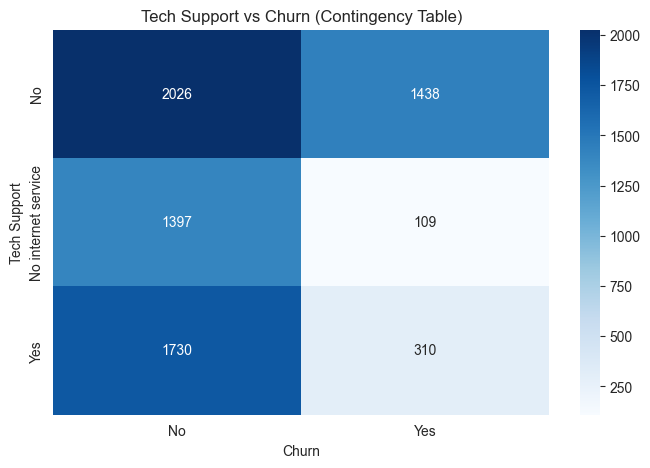

In [120]:
plt.figure(figsize=(8,5))

sns.heatmap(tech_support_table,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Tech Support vs Churn (Contingency Table)")
plt.xlabel("Churn")
plt.ylabel("Tech Support")

plt.show()

### Interpretation

The p-value obtained from the Chi-Square test is less than 0.05, indicating that we reject the null hypothesis.

This means that tech support availability and customer churn are statistically dependent. Customers without tech support services are significantly more likely to churn compared to customers who have access to technical support.

### Business Insight

The results suggest that providing technical support plays an important role in customer retention. Customers without access to tech support may experience unresolved technical issues, leading to dissatisfaction and eventually churn.

Telecom companies can reduce churn by offering improved customer support services, faster issue resolution, and proactive technical assistance.

### 4. _Correlation Analysis_

Correlation analysis is used to measure the strength and direction of relationships between numerical variables in the dataset.

In this analysis, we examine the relationships between tenure, monthly charges, and total charges to understand how these customer attributes interact with each other. Identifying strong correlations can provide insights into customer spending behavior and service usage patterns.

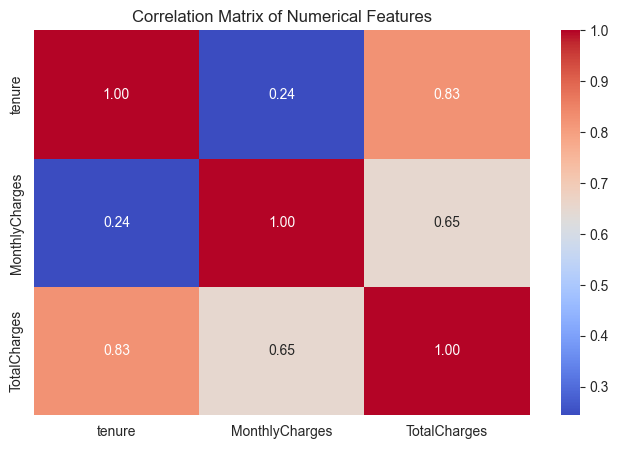

In [121]:
# Select numeric columns
numeric_features = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

# Compute correlation matrix
corr_matrix = numeric_features.corr()

# Plot heatmap
plt.figure(figsize=(8,5))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Matrix of Numerical Features")

plt.show()

### Interpretation

The correlation analysis shows a strong positive relationship between tenure and total charges, indicating that customers who remain with the company for longer periods accumulate higher total spending.

A moderate correlation is also observed between monthly charges and total charges, as total charges are influenced by the monthly billing amount.

However, the correlation between tenure and monthly charges is relatively weak, suggesting that the length of time a customer stays with the company does not strongly influence their monthly subscription cost.

Most churn happens in early tenure.
This feature helps capture that behavior clearly.

## Data Splitting
---

In [122]:
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"No":0, "Yes":1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Feature Engineering

Feature engineering was performed to extract additional signals from the raw telecom dataset and improve the predictive capability of the churn model. The goal was to transform raw attributes into features that better capture **customer behavior, spending patterns, and lifecycle stage**.

In telecom businesses, churn is often influenced by factors such as **customer tenure and spending behavior**. Therefore, additional variables were created to better represent these aspects of customer activity.

---

### Engineered Features

| Feature | Formula / Method | Interpretation |
|-------|------------------|---------------|
| **AvgMonthlySpend** | `TotalCharges / (tenure + 1)` | Estimates the average monthly spending of a customer. This normalizes total charges by the customer's lifetime with the company. |
| **TenureGroup** | Binned tenure into ranges: `0-1yr`, `1-2yr`, `2-4yr`, `4-6yr` | Represents the customer lifecycle stage. Customers in early stages are typically more likely to churn compared to long-term customers. |
| **ChargeLevel** | Monthly charges grouped into `Low`, `Medium`, `High` using quantile-based binning | Captures spending segments of customers. Customers with higher monthly charges may have a greater likelihood of churn if they perceive insufficient value for their cost. |

---

### Business Motivation

Feature engineering was designed to incorporate domain knowledge from telecom customer behavior:

- **Customer lifecycle effects** – Early-stage customers are more likely to churn.
- **Spending behavior** – High or increasing monthly charges may increase churn risk.
- **Customer value patterns** – Understanding spending intensity helps identify high-value customers who may be at risk of leaving.

By incorporating these behavioral indicators, the model gains a richer representation of customer characteristics beyond the original dataset.

---

### Integration with the ML Pipeline

Feature engineering is implemented using a **custom Scikit-Learn transformer**, which allows the transformations to be seamlessly integrated into the machine learning pipeline.

This ensures that:

- Feature transformations are **applied consistently** during both training and prediction.
- The workflow remains **reproducible and production-ready**.
- There is **no data leakage** between training and testing datasets.

The final pipeline structure is:

Feature Engineering → Data Preprocessing → Machine Learning Model


This modular design makes the workflow **scalable, maintainable, and suitable for real-world deployment**.

In [123]:
from src.feature_engineering import FeatureEngineering

## Preprocessing
---
Before training the machine learning models, the dataset was preprocessed to ensure that numerical and categorical variables were handled appropriately. Since machine learning algorithms require numerical inputs and may be sensitive to feature scales, separate preprocessing steps were applied to different types of features.

### Numerical Feature Scaling

The following numerical features were standardized:

- tenure
- MonthlyCharges
- TotalCharges
- AvgMonthlySpend

Standardization was performed using **StandardScaler**, which transforms features so that they have a mean of 0 and a standard deviation of 1.

This step helps machine learning models perform better by ensuring that features with larger numerical ranges do not dominate those with smaller ranges.

### Categorical Feature Encoding

The following categorical variables were encoded:

- Contract
- InternetService
- TechSupport
- TenureGroup
- ChargeLevel

Since machine learning models cannot directly process categorical values, **One-Hot Encoding** was used to convert these variables into numerical binary indicators.

To avoid multicollinearity, the first category of each feature was dropped using `drop='first'`.

Additionally, the encoder was configured with `handle_unknown="ignore"` to ensure that the pipeline can handle unseen categories during prediction without causing errors.

### ColumnTransformer Pipeline

A **ColumnTransformer** was used to apply different preprocessing steps to numerical and categorical features within a single pipeline. This ensures that the same transformations are consistently applied during both model training and prediction.

Integrating preprocessing into the machine learning pipeline helps maintain **reproducibility, prevents data leakage, and simplifies deployment of the model**.

In [124]:
from src.preprocessing import preprocessor

## Model Building
---
Since our dataset is imbalanced, our model should handle this class imbalance.

In [125]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [126]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {classes[i]: weights[i] for i in range(len(classes))}

print(class_weights)

{np.int64(0): np.float64(0.6802523047064531), np.int64(1): np.float64(1.8869448183041724)}


### 1. Logistic Regression Pipeline

In [127]:
log_pipeline = Pipeline([
    ("feature_engineering", FeatureEngineering()),
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

### 2. Random Forest Pipeline

In [128]:
rf_pipeline = Pipeline([
    ("feature_engineering", FeatureEngineering()),
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(random_state=42, class_weight='balanced')),
])

### 3. XGBoost Pipeline

In [129]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

xgb_pipeline = Pipeline([
    ("feature_engineering", FeatureEngineering()),
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42))
])

### Define Hyperparameter Grids

In [130]:
log_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "liblinear"]
}

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20, 5, 7],
    "model__min_samples_split": [2, 5]
}

xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1],
    "model__subsample": [0.8, 1]
}

In [131]:
# cross-validation strategy

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Tune All Models

In [132]:
pipelines = {
    "Logistic Regression": log_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

param_grids = {
    "Logistic Regression": log_params,
    "Random Forest": rf_params,
    "XGBoost": xgb_params
}

best_models = {}
results = {}

for model_name in pipelines:

    print(f"Training {model_name}...")

    grid = GridSearchCV(
        pipelines[model_name],
        param_grids[model_name],
        cv=cv,
        scoring="recall",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_models[model_name] = grid.best_estimator_
    results[model_name] = grid.best_score_

    print("Best Params:", grid.best_params_)
    print("Best Recall:", grid.best_score_)
    print("---------------------------")

Training Logistic Regression...
Best Params: {'model__C': 10, 'model__solver': 'liblinear'}
Best Recall: 0.7913926739430094
---------------------------
Training Random Forest...
Best Params: {'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best Recall: 0.7846767450794296
---------------------------
Training XGBoost...
Best Params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1}
Best Recall: 0.8398323277517908
---------------------------


Three models were trained and tuned (hyperparameter tuning) and XGBoost was found to be the best model based on the recall value.

In [133]:
best_xgb = best_models["XGBoost"]

## Make Predictions on Test Data
---

In [134]:
y_pred = best_xgb.predict(X_test)

In [135]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.69      0.79      1031
           1       0.49      0.83      0.62       371

    accuracy                           0.73      1402
   macro avg       0.71      0.76      0.70      1402
weighted avg       0.81      0.73      0.74      1402



## Threshold Optimization
---

In [136]:
y_prob = best_xgb.predict_proba(X_test)[:,1]

In [137]:
from sklearn.metrics import recall_score, precision_score

thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:

    y_pred = (y_prob >= t).astype(int)

    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    print(f"Threshold: {t:.2f} | Recall: {recall:.3f} | Precision: {precision:.3f}")

Threshold: 0.10 | Recall: 1.000 | Precision: 0.265
Threshold: 0.15 | Recall: 1.000 | Precision: 0.265
Threshold: 0.20 | Recall: 1.000 | Precision: 0.265
Threshold: 0.25 | Recall: 0.989 | Precision: 0.327
Threshold: 0.30 | Recall: 0.962 | Precision: 0.375
Threshold: 0.35 | Recall: 0.949 | Precision: 0.387
Threshold: 0.40 | Recall: 0.930 | Precision: 0.406
Threshold: 0.45 | Recall: 0.849 | Precision: 0.466
Threshold: 0.50 | Recall: 0.833 | Precision: 0.493
Threshold: 0.55 | Recall: 0.774 | Precision: 0.531
Threshold: 0.60 | Recall: 0.598 | Precision: 0.572
Threshold: 0.65 | Recall: 0.391 | Precision: 0.662
Threshold: 0.70 | Recall: 0.221 | Precision: 0.707
Threshold: 0.75 | Recall: 0.000 | Precision: 0.000
Threshold: 0.80 | Recall: 0.000 | Precision: 0.000
Threshold: 0.85 | Recall: 0.000 | Precision: 0.000


C:\Users\tarun\Downloads\miniconda\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tarun\Downloads\miniconda\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tarun\Downloads\miniconda\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Threshold = 0.40

We select a lower threshold because we want to have a higher recall for Class 1 because missing a churn customer is more expensive.

In [138]:
final_threshold = 0.40

## Evaluate Final Model Performance
---

In [139]:
final_pred = (y_prob >= final_threshold).astype(int)

In [140]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, final_pred))
print(classification_report(y_test, final_pred))

[[527 504]
 [ 26 345]]
              precision    recall  f1-score   support

           0       0.95      0.51      0.67      1031
           1       0.41      0.93      0.57       371

    accuracy                           0.62      1402
   macro avg       0.68      0.72      0.62      1402
weighted avg       0.81      0.62      0.64      1402



### Plot F1 score and Recall vs Threshold

In [141]:
from sklearn.metrics import recall_score, f1_score

thresholds = np.arange(0.0, 1.01, 0.01)

recalls = []
f1_scores = []

for t in thresholds:

    y_pred = (y_prob >= t).astype(int)

    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    recalls.append(recall)
    f1_scores.append(f1)

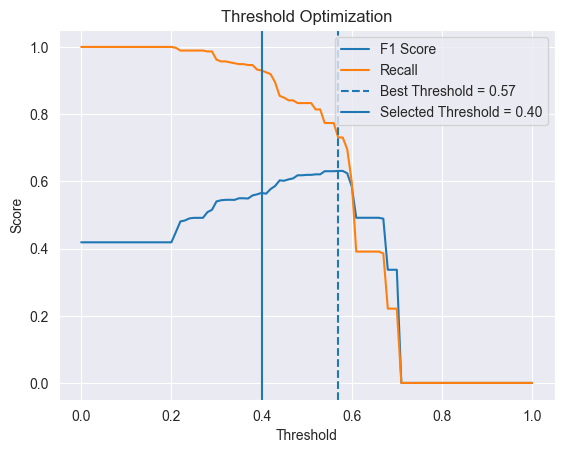

In [142]:
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

plt.figure()

plt.plot(thresholds, f1_scores, label="F1 Score")
plt.plot(thresholds, recalls, label="Recall")

plt.axvline(best_threshold, linestyle="--", label=f"Best Threshold = {best_threshold:.2f}")
plt.axvline(0.40, linestyle="solid", label=f"Selected Threshold = {0.40:.2f}")


plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")

plt.legend()
plt.show()

### ROC Curve and AUC Score

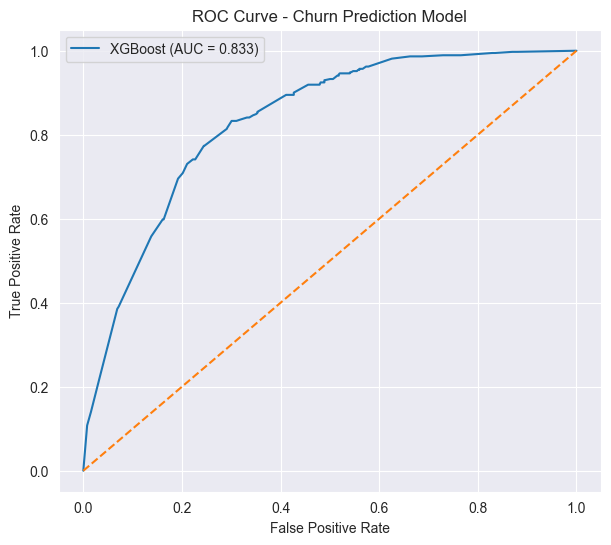

In [154]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict churn probabilities
y_prob = best_xgb.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Compute AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc_score:.3f})")

# Random model reference line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Churn Prediction Model")

plt.legend()
plt.savefig("../figures/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

The ROC-AUC curve was used to evaluate the model's ability to distinguish between customers who churn and those who do not. The XGBoost model achieved an AUC score of 0.83, indicating strong predictive performance.

### Saving the Final Model

In [144]:
import joblib

joblib.dump(best_xgb, "../models/churn_model.pkl")
joblib.dump(final_threshold, "../models/best_threshold.pkl")

['../models/best_threshold.pkl']

## Feature Importance (Using XGBoost Model)
---

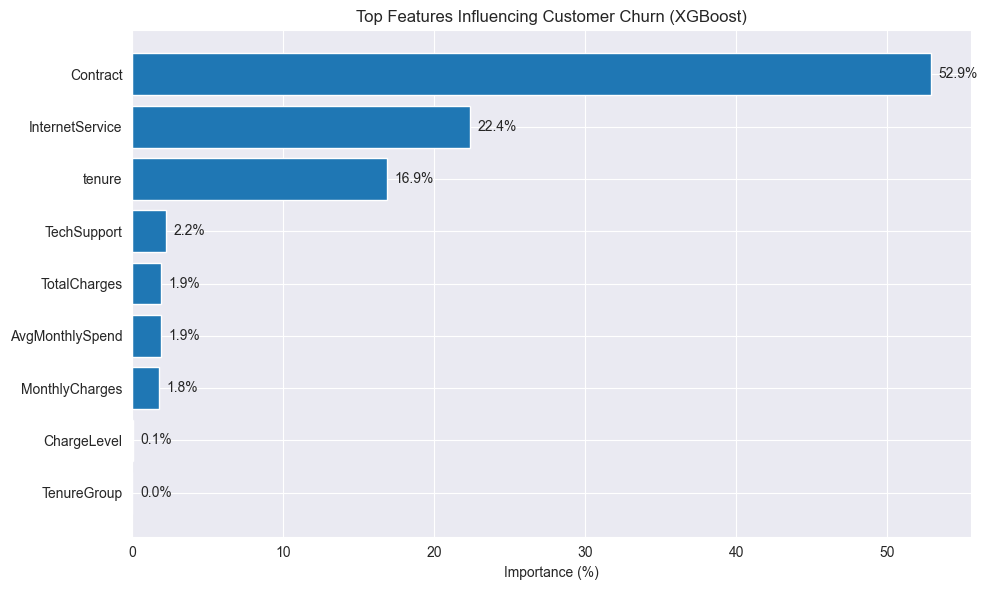

In [152]:
# Extract model and preprocessor
model = best_xgb.named_steps["model"]
preprocessor = best_xgb.named_steps["preprocessing"]

# Get encoded feature names
encoded_features = preprocessor.get_feature_names_out()

# Get feature importances
importances = model.feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    "feature": encoded_features,
    "importance": importances
})

# Remove transformer prefixes
importance_df["feature"] = importance_df["feature"].apply(lambda x: x.split("__")[-1])

# Convert encoded columns back to original features
importance_df["feature"] = importance_df["feature"].apply(lambda x: x.split("_")[0])

# Aggregate importance
importance_df = importance_df.groupby("feature", as_index=False).sum()

# Normalize to percentage
importance_df["importance"] = 100 * importance_df["importance"] / importance_df["importance"].sum()

# Sort
importance_df = importance_df.sort_values("importance", ascending=False)

# Select top 10
top_features = importance_df.head(10).sort_values("importance")

# Plot
plt.figure(figsize=(10,6))

bars = plt.barh(top_features["feature"], top_features["importance"])

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
             f"{width:.1f}%", va='center')

plt.xlabel("Importance (%)")
plt.title("Top Features Influencing Customer Churn (XGBoost)")

plt.savefig("../figures/feature_importance.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

## Customer Risk Segmentation (Using XGBoost Model)
---

In [146]:
# Predict churn probability
churn_prob = best_xgb.predict_proba(X_test)[:, 1]

# Create dataframe from test dataset
test_results = X_test.copy()

# Add churn probability column
test_results["Churn_Probability"] = churn_prob

# Define risk segmentation function
def risk_segment(prob):
    if prob >= 0.70:
        return "High Risk"
    elif prob >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

# Add risk segment column
test_results["Risk_Segment"] = test_results["Churn_Probability"].apply(risk_segment)

# View first rows
test_results.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Probability,Risk_Segment
744,Female,0,No,No,5,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),44.05,202.15,0.583523,Medium Risk
669,Female,0,Yes,No,70,No,No phone service,DSL,No,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),57.80,4039.30,0.219519,Low Risk
5764,Male,1,No,No,57,Yes,Yes,Fiber optic,Yes,No,No,Yes,No,Yes,Two year,No,Electronic check,93.75,5625.55,0.340802,Low Risk
5469,Male,0,No,No,33,Yes,No,Fiber optic,No,Yes,Yes,No,No,No,Month-to-month,Yes,Credit card (automatic),79.00,2576.80,0.608956,Medium Risk
2030,Male,0,No,Yes,2,Yes,Yes,DSL,Yes,Yes,No,No,No,No,Month-to-month,No,Bank transfer (automatic),60.95,134.60,0.591646,Medium Risk


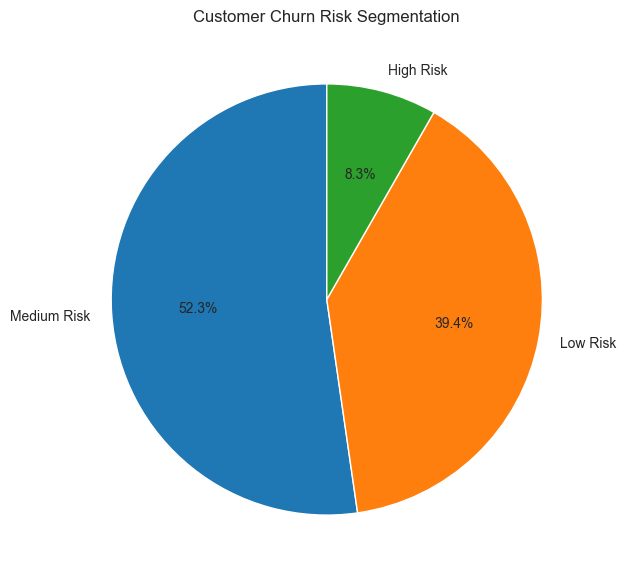

In [153]:
# Count customers in each segment
segment_counts = test_results["Risk_Segment"].value_counts()

# Plot pie chart
plt.figure(figsize=(7,7))

plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Risk Segmentation")
plt.savefig("../figures/risk_segmentation.png", dpi=300, bbox_inches="tight")
plt.show()

## Churn Probability Distribution Plot
---

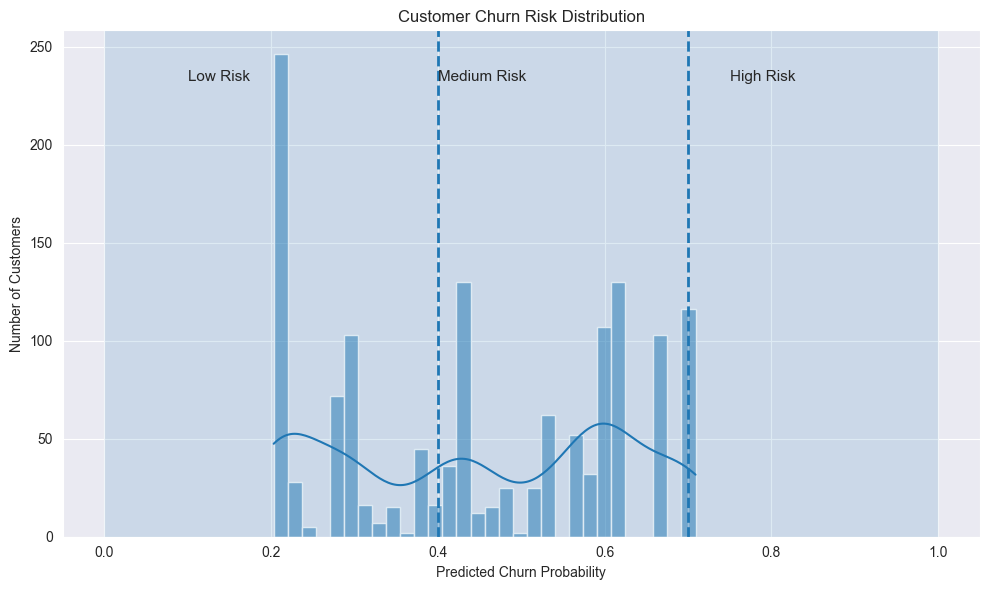

In [167]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get churn probabilities
churn_prob = best_xgb.predict_proba(X_test)[:,1]

plt.figure(figsize=(10,6))

# Histogram
sns.histplot(churn_prob, bins=30, kde=True)

# Risk thresholds
plt.axvline(0.4, linestyle="--", linewidth=2)
plt.axvline(0.7, linestyle="--", linewidth=2)

# Risk zones
plt.axvspan(0, 0.4, alpha=0.15)
plt.axvspan(0.4, 0.7, alpha=0.15)
plt.axvspan(0.7, 1, alpha=0.15)

plt.xlabel("Predicted Churn Probability")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Risk Distribution")

# Risk labels
plt.text(0.1, plt.ylim()[1]*0.9, "Low Risk", fontsize=11)
plt.text(0.4, plt.ylim()[1]*0.9, "Medium Risk", fontsize=11)
plt.text(0.75, plt.ylim()[1]*0.9, "High Risk", fontsize=11)

plt.tight_layout()
plt.show()

## Customer Lifetime Value
---

In [163]:
# Create dataframe for churn risk analysis
risk_df = X_test.copy()

# Add churn probabilities
risk_df["Churn_Probability"] = y_prob

# Add actual churn values
risk_df["Actual_Churn"] = y_test.values

# Estimate Customer Lifetime Value
risk_df["CLV"] = risk_df["MonthlyCharges"] * risk_df["tenure"]

# Expected revenue loss if customer churns
risk_df["ExpectedRevenueLoss"] = (
    risk_df["Churn_Probability"] * risk_df["CLV"]
)

In [164]:
# customers who are both likely to churn and financially important.

risk_df.sort_values(
    by="ExpectedRevenueLoss",
    ascending=False
).head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_Probability,Actual_Churn,CLV,ExpectedRevenueLoss
5252,Male,1,Yes,No,71,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,107.50,7713.55,0.562483,0,7632.50,4293.154324
1661,Female,1,Yes,No,65,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),108.80,7082.45,0.569615,0,7072.00,4028.313953
3783,Female,0,Yes,No,66,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.20,6936.85,0.569615,0,6943.20,3954.947602
402,Male,0,Yes,Yes,69,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),99.45,7007.60,0.569615,1,6862.05,3908.723383
5137,Male,1,No,No,55,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,116.50,6382.55,0.607678,0,6407.50,3893.699434
6306,Male,0,No,No,71,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),116.30,8309.55,0.465771,0,8257.30,3846.014976
2282,Male,1,Yes,Yes,66,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),99.50,6822.15,0.569615,1,6567.00,3740.658616
3751,Male,0,Yes,No,60,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),109.45,6572.85,0.568300,0,6567.00,3732.024983
7023,Female,1,Yes,No,63,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.50,6479.40,0.569615,0,6520.50,3714.171540
511,Male,0,No,No,61,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,106.45,6300.15,0.569615,0,6493.45,3698.763467


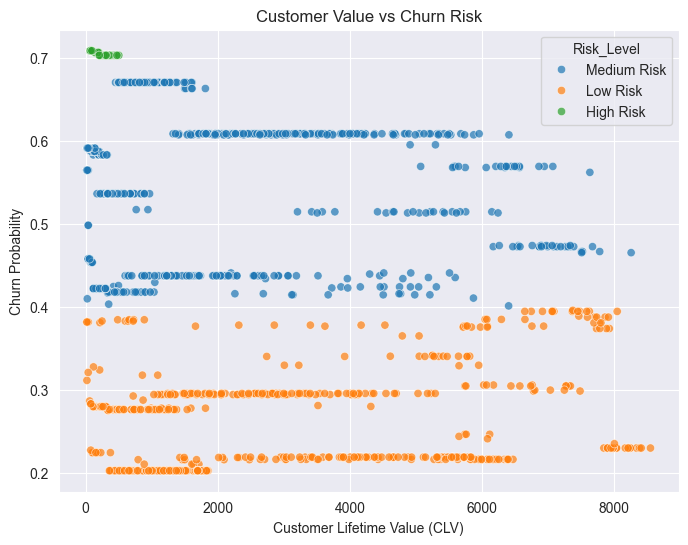

In [166]:
def risk_segment(prob):

    if prob >= 0.70:
        return "High Risk"

    elif prob >= 0.40:
        return "Medium Risk"

    else:
        return "Low Risk"


risk_df["Risk_Level"] = risk_df["Churn_Probability"].apply(risk_segment)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=risk_df,
    x="CLV",
    y="Churn_Probability",
    hue="Risk_Level",
    alpha=0.7
)

plt.title("Customer Value vs Churn Risk")
plt.xlabel("Customer Lifetime Value (CLV)")
plt.ylabel("Churn Probability")

plt.savefig("../figures/churn_value_risk_scatter.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The scatter plot shows the relationship between **Customer Lifetime Value (CLV)** and the **predicted churn probability** for each customer. Customers are grouped into **Low Risk, Medium Risk, and High Risk** categories based on their predicted churn probabilities.

Most customers fall into the low and medium risk segments, while a smaller group of customers is classified as high risk. From a business perspective, customers with **both high CLV and high churn probability** represent the most critical segment, as their departure would result in greater revenue loss. These customers should be prioritized for targeted retention strategies.


## High-Risk Customer Profile
---

In [149]:
# Predict churn probability
churn_prob = best_xgb.predict_proba(X_test)[:,1]

# Create risk segments
risk_levels = pd.cut(
    churn_prob,
    bins=[0,0.3,0.6,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

# Create results dataframe
results = X_test.copy()

results["Churn_Probability"] = churn_prob
results["Risk_Level"] = risk_levels

high_risk_customers = results[results["Risk_Level"] == "High Risk"]

In [150]:
profile = {
    "Avg Tenure": high_risk_customers["tenure"].mean(),
    "Avg Monthly Charges": high_risk_customers["MonthlyCharges"].mean(),
    "Most Common Contract": high_risk_customers["Contract"].mode()[0]
}

profile

{'Avg Tenure': np.float64(18.49484536082474),
 'Avg Monthly Charges': np.float64(85.95180412371133),
 'Most Common Contract': 'Month-to-month'}

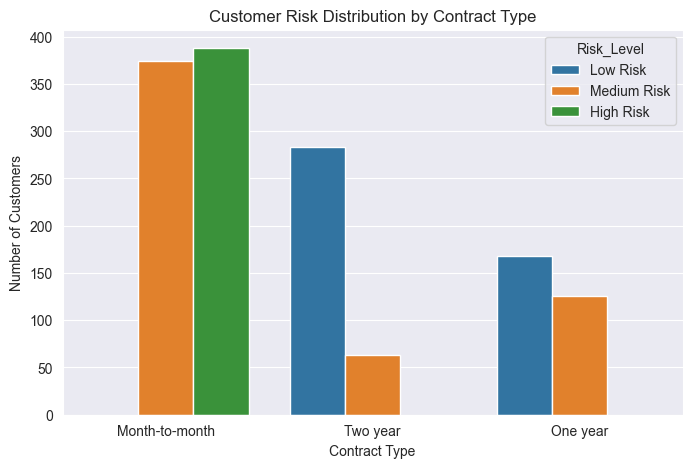

In [155]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=results,
    x="Contract",
    hue="Risk_Level"
)

plt.title("Customer Risk Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.savefig("../figures/risk_contract_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

High-risk customers tend to have shorter tenure and are predominantly on month-to-month contracts. These customers also tend to have relatively high monthly charges, indicating that flexible contracts and pricing sensitivity may contribute to churn behavior.

## Business Recommendations

Based on the exploratory analysis, machine learning modeling, and customer risk segmentation, the following strategies are recommended to reduce customer churn.

---

### 1. Encourage Long-Term Contracts

The analysis shows that customers with **month-to-month contracts** have the highest churn risk. Long-term contracts significantly reduce churn probability.

**Recommendations**

- Provide incentives for customers to switch to **1-year or 2-year contracts**
- Offer **discounts for long-term commitments**
- Introduce **contract upgrade campaigns**

**Expected Impact**

- Improved customer retention
- More stable and predictable revenue streams

---

### 2. Focus on Early Customer Retention

Customers with **short tenure** were found to have a higher probability of churn.

**Recommendations**

- Implement a **customer onboarding program**
- Provide **early engagement offers within the first 3–6 months**
- Monitor new customers using **churn risk scores**

**Expected Impact**

- Increased customer lifetime value
- Reduced early-stage churn

---

### 3. Target High-Risk Customers with Retention Campaigns

The machine learning model identifies customers with **high churn probability (> 0.7)** who are most likely to leave.

**Recommendations**

- Prioritize **high-risk customers for retention campaigns**
- Offer **personalized discounts or service upgrades**
- Provide **proactive customer support outreach**

**Expected Impact**

- Reduced churn among the most vulnerable customers
- Better allocation of retention resources

---

### 4. Implement a Churn Monitoring System

The developed machine learning model can be used as a **decision-support tool** for ongoing churn monitoring.

**Recommendations**

- Deploy the model to **regularly score customers**
- Segment customers into **Low Risk, Medium Risk, and High Risk groups**
- Integrate churn predictions into **customer relationship management systems**

**Expected Impact**

- Proactive churn prevention
- Data-driven retention strategies

---

## Project Summary

This project developed a **customer churn prediction system** using machine learning techniques. Multiple models were evaluated, and the **XGBoost model** achieved the highest recall for churn customers.

The model's predicted probabilities were used to segment customers into **risk groups**, enabling targeted retention strategies and actionable business insights.

The final workflow includes:

- Exploratory Data Analysis (EDA)
- Feature Engineering
- Machine Learning Pipelines
- Handling Class Imbalance
- Model Comparison
- Feature Importance Analysis
- Churn Probability Prediction
- Customer Risk Segmentation
- High-Risk Customer Profiling
- Business Recommendations